In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler,MinMaxScaler
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [3]:
url='https://raw.githubusercontent.com/sachin365123/CSV-files-for-Data-Science-and-Machine-Learning/main/Loan%20Approval%20Prediction.csv'
df=pd.read_csv(url)

In [4]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [5]:
df.isnull().mean()*100

Loan_ID              0.000000
Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       8.143322
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [6]:
null_col=[var for var in df.columns if df[var].isnull().mean()<0.05 and df[var].isnull().mean()>0]
df.dropna(subset=null_col,inplace=True)

In [7]:
df.isnull().mean()*100

Loan_ID              0.000000
Gender               0.000000
Married              0.000000
Dependents           0.000000
Education            0.000000
Self_Employed        5.424955
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           0.000000
Loan_Amount_Term     0.000000
Credit_History       8.679928
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [8]:
X=df.drop(columns=['Loan_ID','Loan_Status'])
y=df['Loan_Status']

In [9]:
tf1=ColumnTransformer([
    ('tf1',SimpleImputer(),['Credit_History']),
    ('tf2',SimpleImputer(strategy='most_frequent'),['Self_Employed'])
],remainder='passthrough',verbose_feature_names_out=False)
tf1.set_output(transform='pandas')
X_imputed=tf1.fit_transform(X)
X_imputed

,Credit_History,Self_Employed,Gender,Married,Dependents,Education,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Property_Area
1,1.0,No,Male,Yes,1,Graduate,4583,1508.0,128.0,360.0,Rural
2,1.0,Yes,Male,Yes,0,Graduate,3000,0.0,66.0,360.0,Urban
3,1.0,No,Male,Yes,0,Not Graduate,2583,2358.0,120.0,360.0,Urban
4,1.0,No,Male,No,0,Graduate,6000,0.0,141.0,360.0,Urban
5,1.0,Yes,Male,Yes,2,Graduate,5417,4196.0,267.0,360.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...
609,1.0,No,Female,No,0,Graduate,2900,0.0,71.0,360.0,Rural
610,1.0,No,Male,Yes,3+,Graduate,4106,0.0,40.0,180.0,Rural
611,1.0,No,Male,Yes,1,Graduate,8072,240.0,253.0,360.0,Urban
612,1.0,No,Male,Yes,2,Graduate,7583,0.0,187.0,360.0,Urban


In [10]:
num_cols = ['ApplicantIncome','CoapplicantIncome','LoanAmount',
            'Loan_Amount_Term','Credit_History']

ohe_cols = ['Gender','Married','Self_Employed']

ord_cols = ['Dependents','Education','Property_Area']

In [11]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y_transformed=le.fit_transform(y)
y_transformed

array([0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1,

In [12]:
X_imputed.isnull().sum()

Credit_History       0
Self_Employed        0
Gender               0
Married              0
Dependents           0
Education            0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Property_Area        0
dtype: int64

In [13]:
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

In [15]:
cat_ord_pipeline = Pipeline([
    ('ordinal', OrdinalEncoder(categories=[
        ['0','1','2','3+'],
        ['Not Graduate','Graduate'],
        ['Rural','Semiurban','Urban']
    ]))
])

In [14]:
cat_ohe_pipeline = Pipeline([
    ('ohe', OneHotEncoder(drop='first',
                          handle_unknown='ignore',
                          sparse_output=False))
])

In [16]:
preprocess = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('ohe', cat_ohe_pipeline, ohe_cols),
    ('ord', cat_ord_pipeline, ord_cols)
], remainder='passthrough',verbose_feature_names_out=False)
preprocess.set_output(transform='pandas')
X_transformed = preprocess.fit_transform(X_imputed)
X_transformed

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Self_Employed_Yes,Dependents,Education,Property_Area
1,-0.128694,-0.049699,-0.214368,0.279961,0.423254,1.0,1.0,0.0,1.0,1.0,0.0
2,-0.394296,-0.545638,-0.952675,0.279961,0.423254,1.0,1.0,1.0,0.0,1.0,2.0
3,-0.464262,0.229842,-0.309634,0.279961,0.423254,1.0,1.0,0.0,0.0,0.0,2.0
4,0.109057,-0.545638,-0.059562,0.279961,0.423254,1.0,0.0,0.0,0.0,1.0,2.0
5,0.011239,0.834309,1.440866,0.279961,0.423254,1.0,1.0,1.0,2.0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...
609,-0.411075,-0.545638,-0.893134,0.279961,0.423254,0.0,0.0,0.0,0.0,1.0,0.0
610,-0.208727,-0.545638,-1.262287,-2.468292,0.423254,1.0,1.0,0.0,3.0,1.0,0.0
611,0.456706,-0.466709,1.274152,0.279961,0.423254,1.0,1.0,0.0,1.0,1.0,2.0
612,0.374659,-0.545638,0.488213,0.279961,0.423254,1.0,1.0,0.0,2.0,1.0,2.0


In [23]:
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegression())
])


In [24]:
X_train,X_test,y_train,y_test=train_test_split(X_imputed,y_transformed,test_size=0.2)

In [25]:
pipe.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('ohe', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [26]:
y_pred=pipe.predict(X_test)

In [27]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8108108108108109

In [28]:
cross_val_score(pipe,X_train,y_train).mean()

np.float64(0.8008426966292135)

# WIth auto Gridsearchcv

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler,MinMaxScaler,RobustScaler
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

In [3]:
url='https://raw.githubusercontent.com/sachin365123/CSV-files-for-Data-Science-and-Machine-Learning/main/Loan%20Approval%20Prediction.csv'
df=pd.read_csv(url)

In [4]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [5]:
X=df.drop(columns=['Loan_ID','Loan_Status'])
y=df['Loan_Status']
X

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban


In [6]:
X.isnull().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
dtype: int64

In [7]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    object 
 1   Married            611 non-null    object 
 2   Dependents         599 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      582 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   600 non-null    float64
 9   Credit_History     564 non-null    float64
 10  Property_Area      614 non-null    object 
dtypes: float64(4), int64(1), object(6)
memory usage: 52.9+ KB


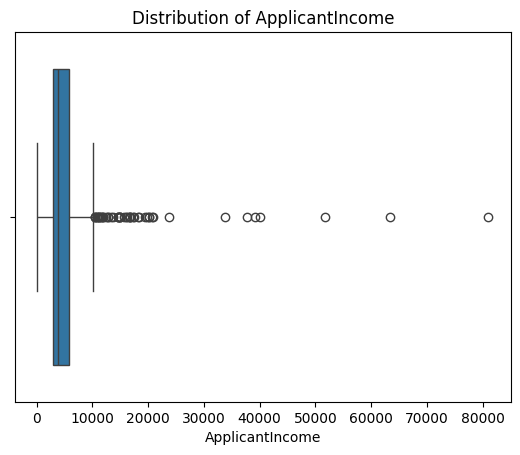

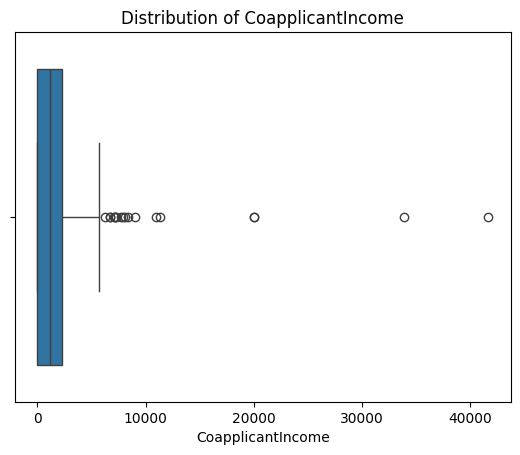

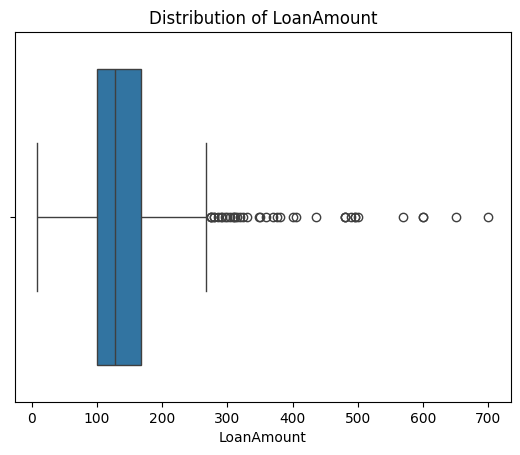

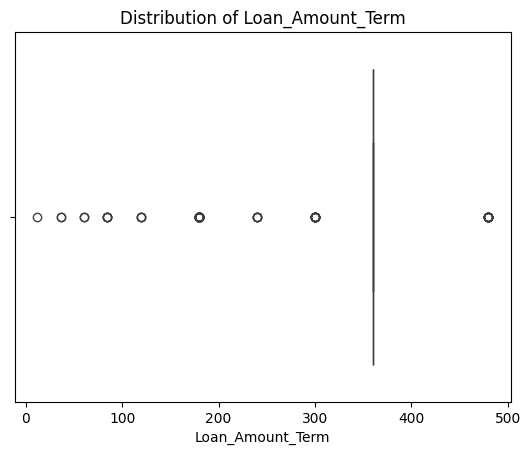

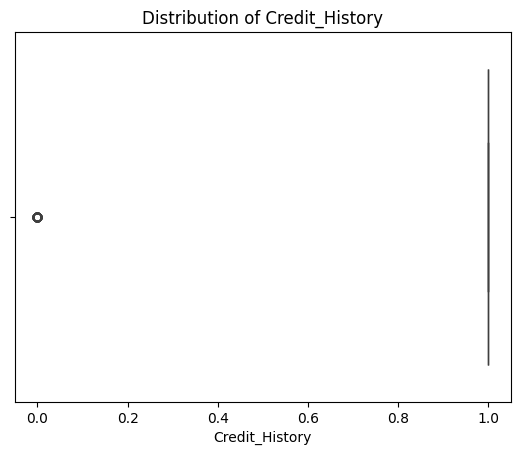

In [8]:
for col in X.select_dtypes(include='number').columns:
    sns.boxplot(x=df[col]) # Explicitly set x for horizontal plots
    plt.title(f'Distribution of {col}')
    plt.show()

In [9]:
from sklearn.base import BaseEstimator, TransformerMixin

class OutlierHandler(BaseEstimator, TransformerMixin):

    def __init__(self, lower_percentile=25, upper_percentile=75, factor=1.5):
        self.lower_percentile = lower_percentile
        self.upper_percentile = upper_percentile
        self.factor = factor

    def fit(self, X, y=None):
        self.q1 = np.percentile(X, self.lower_percentile, axis=0)
        self.q3 = np.percentile(X, self.upper_percentile, axis=0)
        self.iqr = self.q3 - self.q1

        self.lower_bound = self.q1 - self.factor * self.iqr
        self.upper_bound = self.q3 + self.factor * self.iqr

        return self

    def transform(self, X):
        return np.clip(X, self.lower_bound, self.upper_bound)

    def set_output(self, transform=None):
        return self

In [16]:
num_cols = ['ApplicantIncome','CoapplicantIncome','LoanAmount',
            'Loan_Amount_Term','Credit_History']

ohe_cols = ['Gender','Married','Self_Employed']

ord_cols = ['Dependents','Education','Property_Area']

In [17]:
num_pipeline = Pipeline([
    ('imputer',SimpleImputer()),
    ('outlier', OutlierHandler(lower_percentile=10,upper_percentile=90,factor=0)),
    ('scaler', StandardScaler())
])

In [18]:
cat_ord_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[
        ['0','1','2','3+'],
        ['Not Graduate','Graduate'],
        ['Rural','Semiurban','Urban']
    ]))
])

In [19]:
cat_ohe_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first',
                          handle_unknown='ignore',
                          sparse_output=False))
])

In [20]:
preprocess = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('ohe', cat_ohe_pipeline, ohe_cols),
    ('ord', cat_ord_pipeline, ord_cols)
], remainder='passthrough',verbose_feature_names_out=False)
preprocess.set_output(transform='pandas')
X_transformed = preprocess.fit_transform(X)
X_transformed

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Self_Employed_Yes,Dependents,Education,Property_Area
0,0.548362,-0.951217,0.200068,0.387769,0.451640,1.0,0.0,0.0,0.0,1.0,2.0
1,-0.007092,0.151248,-0.191610,0.387769,0.451640,1.0,1.0,0.0,1.0,1.0,0.0
2,-0.701630,-0.951217,-1.376506,0.387769,0.451640,1.0,1.0,1.0,0.0,1.0,2.0
3,-0.884588,0.772664,-0.361793,0.387769,0.451640,1.0,1.0,0.0,0.0,0.0,2.0
4,0.614613,-0.951217,0.084936,0.387769,0.451640,1.0,0.0,0.0,0.0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...
609,-0.745505,-0.951217,-1.376506,0.387769,0.451640,0.0,0.0,0.0,0.0,1.0,0.0
610,-0.216375,-0.951217,-1.376506,-2.696303,0.451640,1.0,1.0,0.0,3.0,1.0,0.0
611,1.523699,-0.775758,1.965454,0.387769,0.451640,1.0,1.0,0.0,1.0,1.0,2.0
612,1.309151,-0.951217,1.063486,0.387769,0.451640,1.0,1.0,0.0,2.0,1.0,2.0


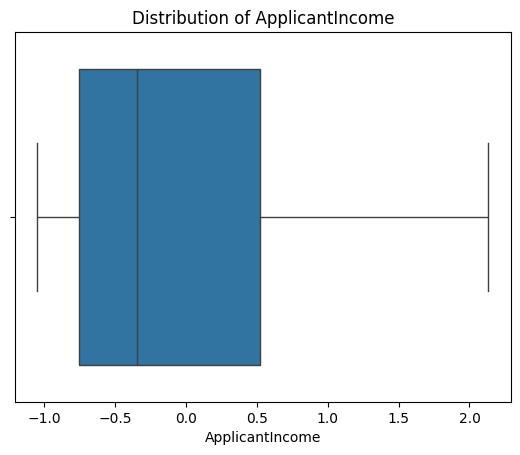

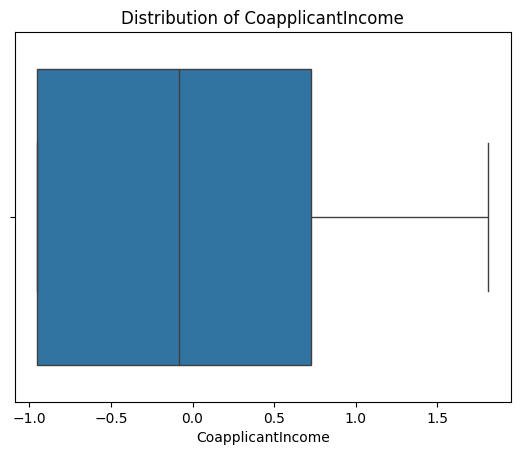

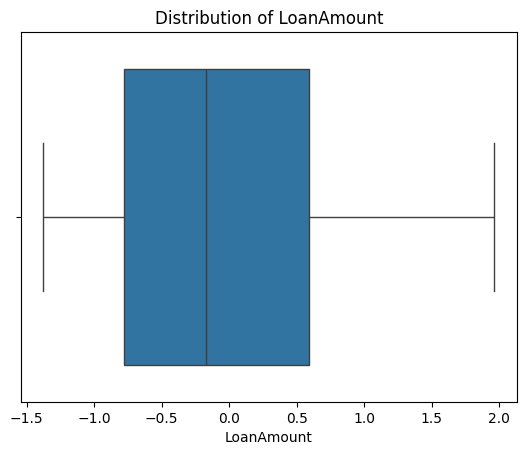

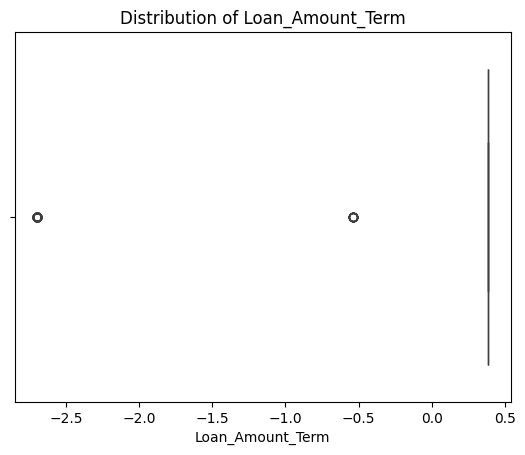

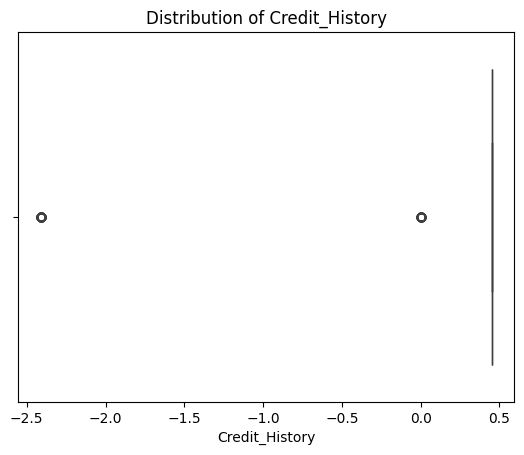

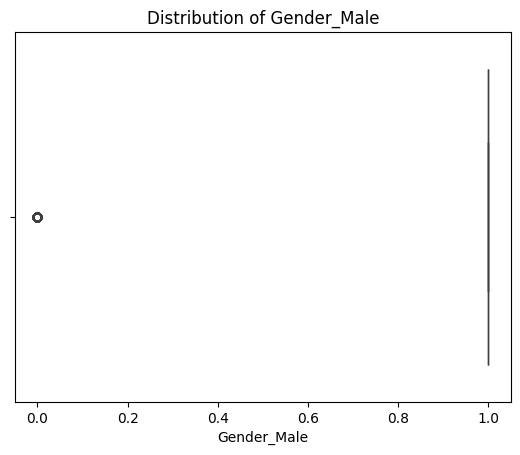

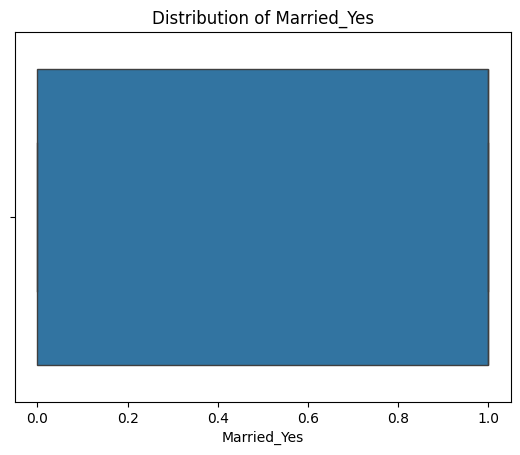

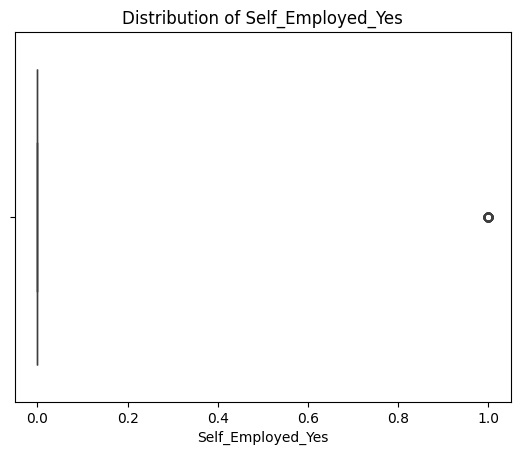

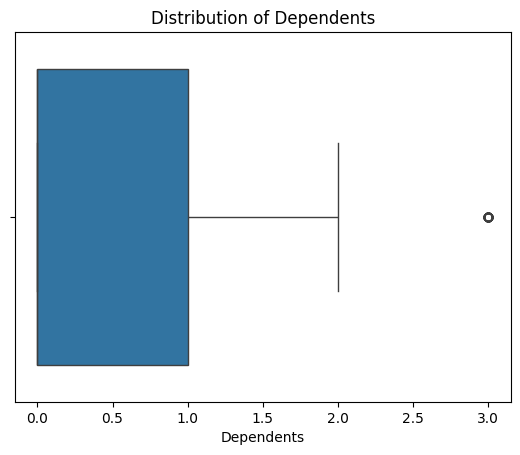

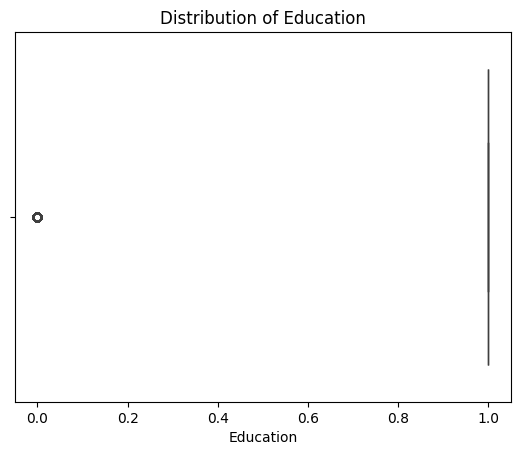

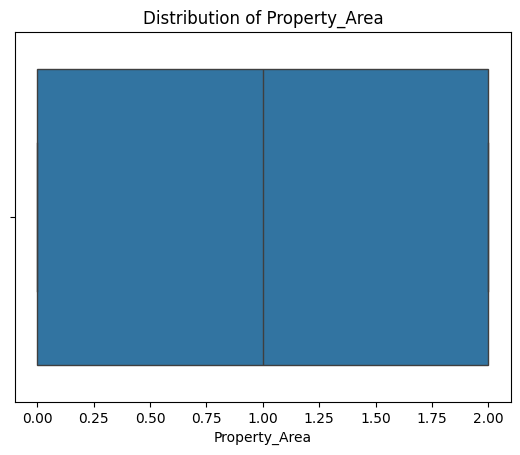

In [21]:
for col in X_transformed.select_dtypes(include='number').columns:
    sns.boxplot(x=X_transformed[col]) # Explicitly set x for horizontal plots
    plt.title(f'Distribution of {col}')
    plt.show()

In [22]:
le=LabelEncoder()
y_transformed=le.fit_transform(y)

In [23]:
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegression())
])

In [24]:
params={
    'preprocess__num__imputer__strategy':['mean','median'],
    'preprocess__num__imputer__add_indicator':[True,False],
    'preprocess__ohe__imputer__add_indicator':[True,False],
    'preprocess__ohe__imputer__add_indicator':[True,False],
    'model__C':[0.1,0.01,0.001,0.5,1.0,2.0,5.0]
}

In [25]:
grid=GridSearchCV(pipe,param_grid=params,scoring='accuracy',cv=10, n_jobs=-1)

In [26]:
X_train,X_test,y_train,y_test=train_test_split(X,y_transformed,test_size=0.2)

In [27]:
grid.fit(X_train, y_train)

,estimator,Pipeline(step...egression())])
,param_grid,"{'model__C': [0.1, 0.01, ...], 'preprocess__num__imputer__add_indicator': [True, False], 'preprocess__num__imputer__strategy': ['mean', 'median'], 'preprocess__ohe__imputer__add_indicator': [True, False]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('ohe', ...), ...]"


In [28]:
grid.best_params_

{'model__C': 1.0,
 'preprocess__num__imputer__add_indicator': True,
 'preprocess__num__imputer__strategy': 'mean',
 'preprocess__ohe__imputer__add_indicator': True}

In [29]:
grid.best_score_

np.float64(0.8045714285714286)

In [30]:
y_pred=grid.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8292682926829268